# Latency Bench Plotting

This notebook mirrors `plot_results.sh`, but calls the latency bench plotting API directly so plot inputs, labels, and layout options can be edited in one place.

In [1]:
from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    path = Path.cwd() if start is None else start
    for candidate in (path.resolve(), *path.resolve().parents):
        if (candidate / "tools" / "latency_bench").is_dir():
            return candidate
    raise RuntimeError("failed to find Vortex repository root")


REPO_ROOT = find_repo_root()
LATENCY_DIR = REPO_ROOT / "analysis_workspace" / "latency_on_hw"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from IPython.display import Image, display
from tools.latency_bench.plot import SuiteBarPlotOptions, plot_suite_bar_grid, prepare_suite_bar_data
from tools.latency_bench.suite import load_suite

REPO_ROOT, LATENCY_DIR

(PosixPath('/home/jaeyongjang/project.local/vortex'),
 PosixPath('/home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw'))

In [2]:
# Use original workload suites for model-level comparison. Generated/merged suites are execution shards.
SUITE_TYPE="test2"
OUTPUT_DIR="outputs_test2"
SUITES = [
    LATENCY_DIR / f"suites/{SUITE_TYPE}/llama2_7b_prefill_C1.yaml",
    LATENCY_DIR / f"suites/{SUITE_TYPE}/llama2_7b_prefill_C2.yaml",
    LATENCY_DIR / f"suites/{SUITE_TYPE}/llama2_7b_prefill_C3.yaml",
    LATENCY_DIR / f"suites/{SUITE_TYPE}/llama2_7b_prefill_C4_alone.yaml",
    LATENCY_DIR / f"suites/{SUITE_TYPE}/llama2_7b_prefill_C4_fused.yaml",
    LATENCY_DIR / f"suites/{SUITE_TYPE}/llama2_7b_generation_C1.yaml",
    LATENCY_DIR / f"suites/{SUITE_TYPE}/llama2_7b_generation_C2.yaml",
    LATENCY_DIR / f"suites/{SUITE_TYPE}/llama2_7b_generation_C3.yaml",
    LATENCY_DIR / f"suites/{SUITE_TYPE}/llama2_7b_generation_C4_alone.yaml",
    LATENCY_DIR / f"suites/{SUITE_TYPE}/llama2_7b_generation_C4_fused.yaml",
]
RAW_DBS = [
    LATENCY_DIR / f"{OUTPUT_DIR}/naive_simd/raw_db.csv",
    LATENCY_DIR / f"{OUTPUT_DIR}/naive_gemm_tcol32/raw_db.csv",
    LATENCY_DIR / f"{OUTPUT_DIR}/improve_tcol32/raw_db.csv",
]
OUT_DIR = LATENCY_DIR / f"{OUTPUT_DIR}/figures_notebook"

# Measurement and axis controls.
METRIC = "p50_us"
SELECT = "latest"
MISSING = "nan"  # Use "error" for final reporting after all measurements exist.
X_AXIS = "seq_len"
HUE_AXIS = "variant"
ROW_AXIS = "stage"
COL_AXIS = "batch"
STACKED = True
STACK_BY = "name"
VALUE_LABELS = True
RELATIVE = True
RELATIVE_SCOPE = "x_tick"  # global, subplot, or x_tick
SHARE_Y = False

# Presentation controls. Values not listed here keep their raw DB/suite text.
AXIS_LABEL_MAP = {
    "seq_len": "sequence length",
    "variant": "variant",
    "stage": "stage",
    "batch": "batch",
    "name": "kernel",
}
LABEL_MAPS = {
    "stage": {"prefill": "Prefill", "generation": "Generation"},
    "variant": {
        "all_fpint_gemm_improve_alone_layout_spinquant": "C4-alone",
        "all_fpint_gemm_improve_fused_layout_spinquant": "C4-fused",
        "all_fpint_gemm_naive_spinquant": "C3",
        "all_sgemm_tcu_spinquant": "C1",
        "attn_sgemm_tcu_fpint_gemm_naive_spinquant": "C2",
    },
    "name": {},
}
VALUE_ORDERS = {
    "variant": [
        "all_sgemm_tcu_spinquant",
        "attn_sgemm_tcu_fpint_gemm_naive_spinquant",
        "all_fpint_gemm_naive_spinquant",
        "all_fpint_gemm_improve_alone_layout_spinquant",
        "all_fpint_gemm_improve_fused_layout_spinquant",
    ],
}

FIGURE_TITLE = None
SUBPLOT_TITLE_TEMPLATE = "{row_axis_label}={row_value_label}, {col_axis_label}={col_value_label}"
X_LABEL = "sequence length"
Y_LABEL = None
LEGEND_TITLE = "kernel" if STACKED else "variant"
LEGEND_POSITION = "right"  # right, bottom, top, or none
LEGEND_NCOL = None

In [3]:
missing_inputs = [path for path in [*SUITES, *RAW_DBS] if not path.exists()]
if missing_inputs:
    raise FileNotFoundError("missing plot inputs:\n" + "\n".join(str(path) for path in missing_inputs))

suites = [load_suite(path, repo_root=REPO_ROOT) for path in SUITES]
options = SuiteBarPlotOptions(
    raw_dbs=tuple(RAW_DBS),
    out_dir=OUT_DIR,
    metric=METRIC,
    select=SELECT,
    missing=MISSING,
    x=X_AXIS,
    hue=HUE_AXIS,
    row=ROW_AXIS,
    col=COL_AXIS,
    stacked=STACKED,
    stack_by=STACK_BY,
    value_labels=VALUE_LABELS,
    relative=RELATIVE,
    relative_scope=RELATIVE_SCOPE,
    share_y=SHARE_Y,
    legend_position=LEGEND_POSITION,
    legend_ncol=LEGEND_NCOL,
    figure_title=FIGURE_TITLE,
    subplot_title_template=SUBPLOT_TITLE_TEMPLATE,
    x_label=X_LABEL,
    y_label=Y_LABEL,
    legend_title=LEGEND_TITLE,
    axis_label_map=AXIS_LABEL_MAP,
    label_maps=LABEL_MAPS,
    value_orders=VALUE_ORDERS,
)

composed, plot_data, stack_data = prepare_suite_bar_data(suites, options)
OUT_DIR.mkdir(parents=True, exist_ok=True)
composed.to_csv(OUT_DIR / "composed_cases.csv", index=False)
plot_data.to_csv(OUT_DIR / "plot_data.csv", index=False)
stack_data.to_csv(OUT_DIR / "plot_stack_data.csv", index=False)
plot_suite_bar_grid(plot_data, stack_data, options)

print(f"wrote {OUT_DIR}")
plot_data.head()

wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_test2/figures_notebook


,metric,stage,seq_len,batch,variant,total_latency_us,case_count,pass_case_count,missing_case_count,source_suites,source_raw_dbs,expected_fpga_bin_labels,source_fpga_bin_labels
0,p50_us,generation,1,1,all_fpint_gemm_improve_alone_layout_spinquant,873467.456,10,10,0,llama2_7b_generation_C4_alone,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
1,p50_us,generation,1,1,all_fpint_gemm_improve_fused_layout_spinquant,1066938.304,10,10,0,llama2_7b_generation_C4_fused,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
2,p50_us,generation,1,1,all_fpint_gemm_naive_spinquant,873467.456,10,10,0,llama2_7b_generation_C3,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
3,p50_us,generation,1,1,all_sgemm_tcu_spinquant,873467.456,10,10,0,llama2_7b_generation_C1,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
4,p50_us,generation,1,1,attn_sgemm_tcu_fpint_gemm_naive_spinquant,873467.456,10,10,0,llama2_7b_generation_C2,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd


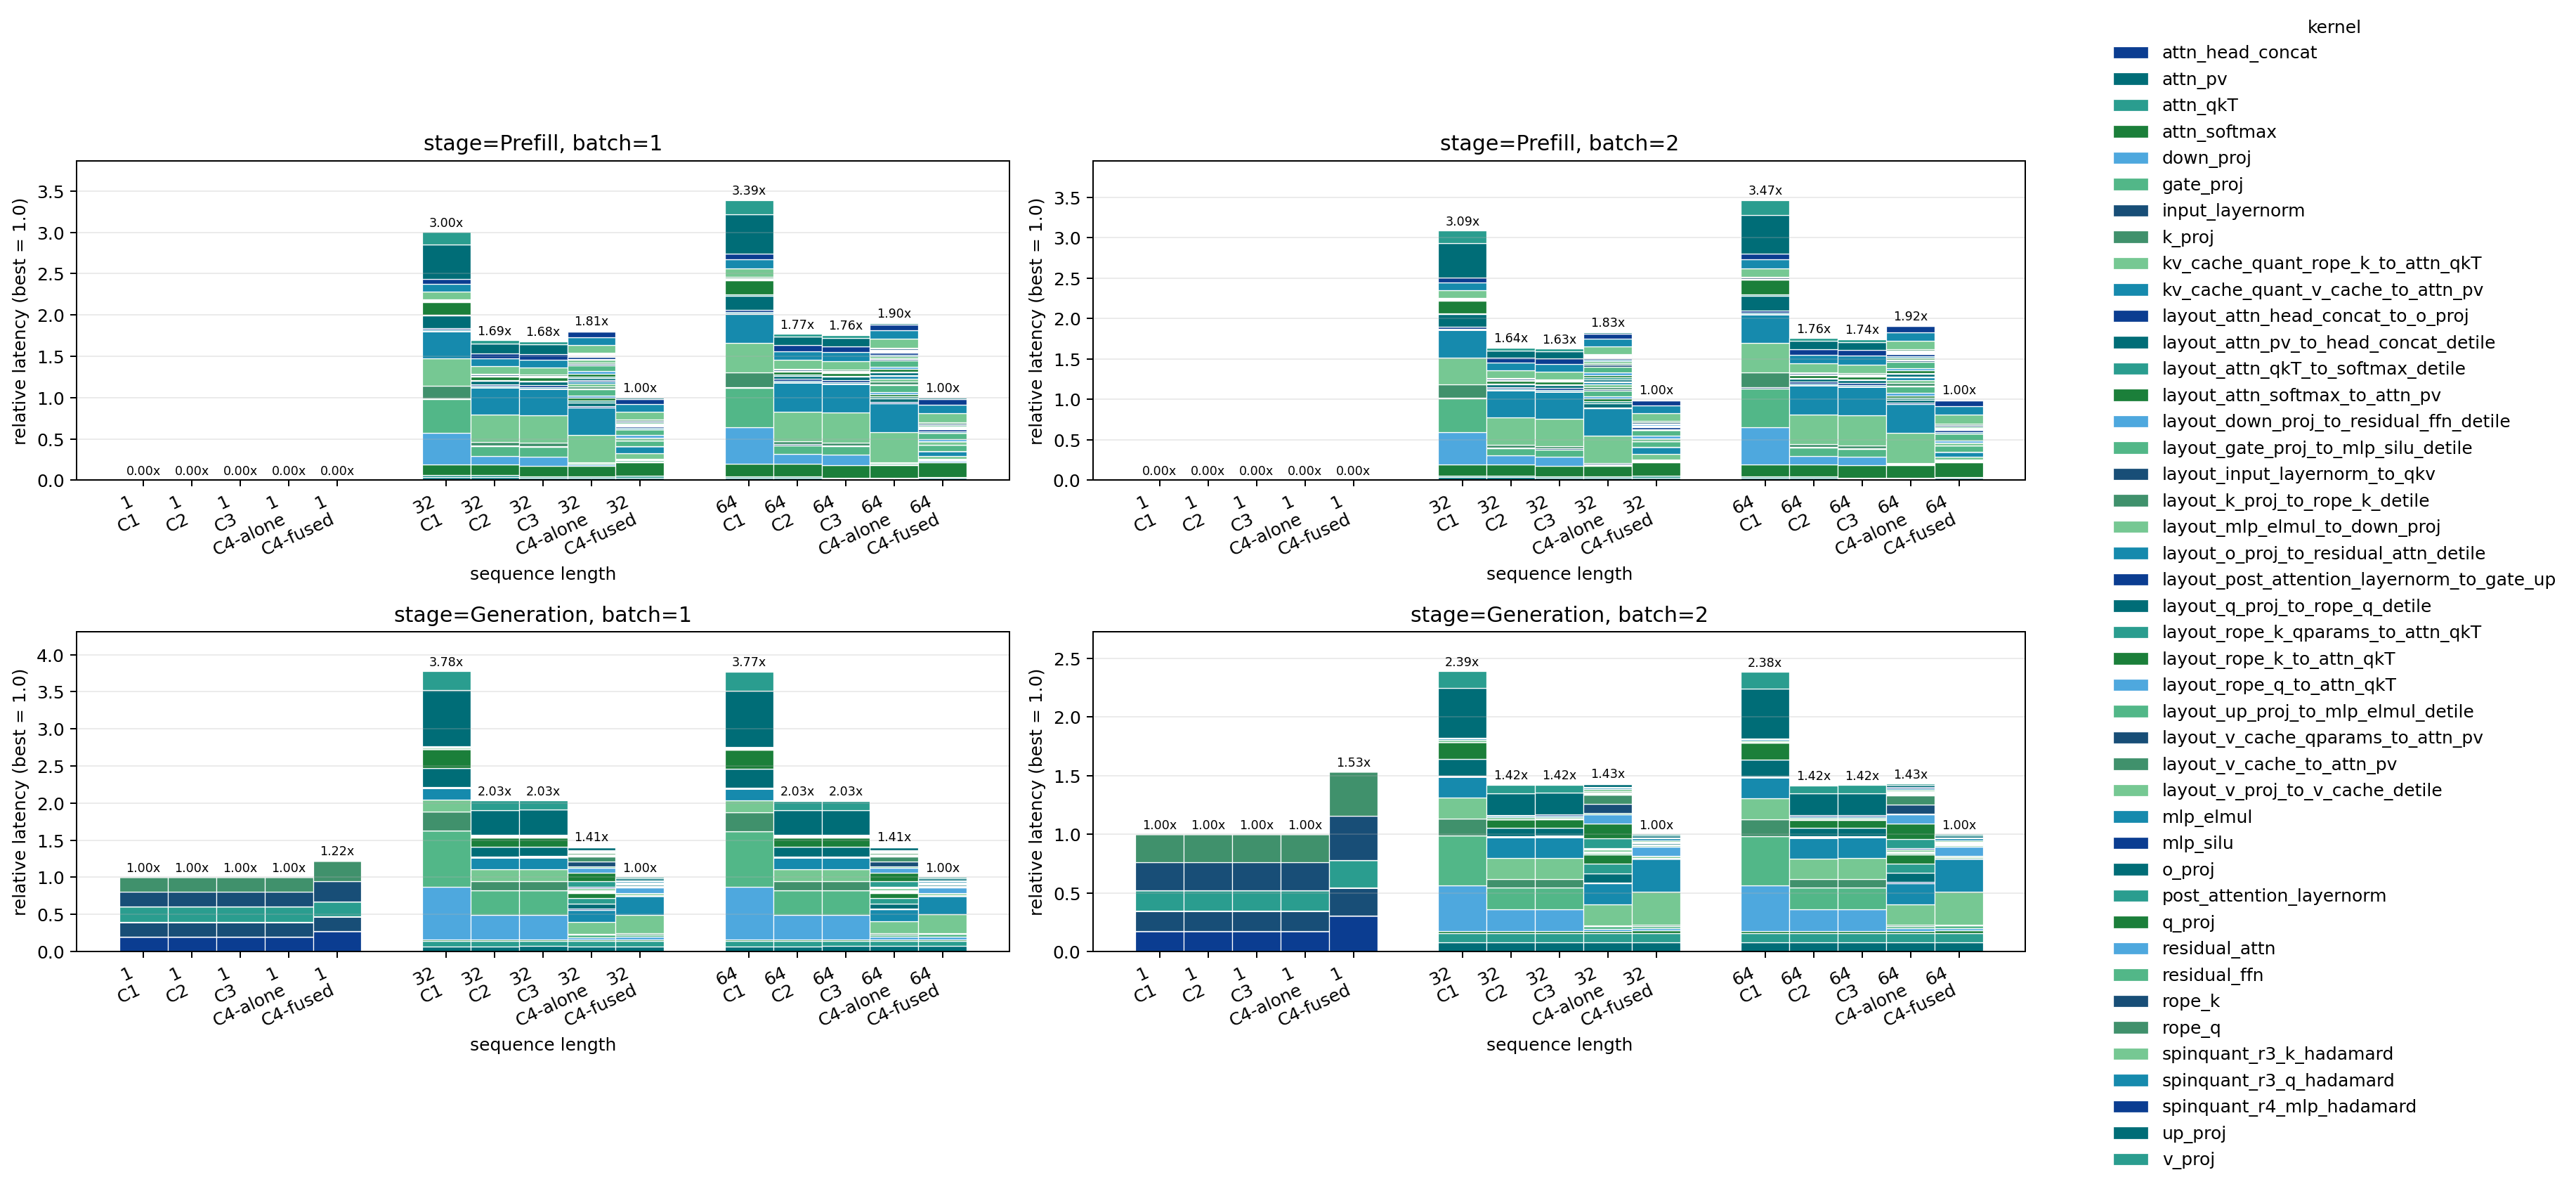

PosixPath('/home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_test2/figures_notebook/bar_total_p50_us.png')

In [4]:
figure_path = OUT_DIR / f"bar_total_{METRIC}.png"
display(Image(filename=str(figure_path)))
figure_path

## Stacked Bar Debugging

Use this section to inspect which stacked components are included in each hue for a selected subplot/x tick. Set a debug filter to `None` to keep all values for that axis.

In [5]:
# Debug controls. These default to one visible x tick in the current plot.
DEBUG_STAGE = "prefill"
DEBUG_BATCH = 1
DEBUG_SEQ_LEN = 512
DEBUG_VARIANTS = None  # e.g. ["all_sgemm_tcu_spinquant", "all_fpint_gemm_naive_spinquant"]
DEBUG_MIN_US = 0.0


def debug_label(axis: str, value):
    mapping = LABEL_MAPS.get(axis, {})
    return mapping.get(value, mapping.get(str(value), str(value)))


def optional_filter(df, column: str, value):
    if value is None:
        return df
    if isinstance(value, (list, tuple, set)):
        return df[df[column].isin(value)]
    return df[df[column] == value]


debug_plot = plot_data.copy()
debug_stack = stack_data.copy()
for column, value in (("stage", DEBUG_STAGE), ("batch", DEBUG_BATCH), ("seq_len", DEBUG_SEQ_LEN)):
    debug_plot = optional_filter(debug_plot, column, value)
    debug_stack = optional_filter(debug_stack, column, value)
if DEBUG_VARIANTS is not None:
    debug_plot = optional_filter(debug_plot, "variant", DEBUG_VARIANTS)
    debug_stack = optional_filter(debug_stack, "variant", DEBUG_VARIANTS)
if DEBUG_MIN_US > 0:
    debug_stack = debug_stack[debug_stack["total_latency_us"] >= DEBUG_MIN_US]

bar_key_cols = ["stage", "batch", "seq_len", "variant"]
bar_totals = debug_plot[
    [
        *bar_key_cols,
        "total_latency_us",
        "case_count",
        "missing_case_count",
        "expected_fpga_bin_labels",
        "source_fpga_bin_labels",
        "source_suites",
    ]
].rename(columns={"total_latency_us": "bar_total_us"})

debug_components = debug_stack.merge(
    bar_totals[[*bar_key_cols, "bar_total_us"]],
    on=bar_key_cols,
    how="left",
)
debug_components["share_pct"] = (
    debug_components["total_latency_us"] / debug_components["bar_total_us"] * 100.0
).where(debug_components["bar_total_us"] > 0, 0.0)
debug_components["variant_label"] = debug_components["variant"].map(lambda value: debug_label("variant", value))
debug_components["component_label"] = debug_components["stack_key"].map(lambda value: debug_label(STACK_BY, value))

display(bar_totals.sort_values(["stage", "batch", "seq_len", "variant"]))

,stage,batch,seq_len,variant,bar_total_us,case_count,missing_case_count,expected_fpga_bin_labels,source_fpga_bin_labels,source_suites


In [6]:
# Which components are included in each hue/bar?
included_components = (
    debug_components[debug_components["total_latency_us"] > 0]
    .sort_values(["stage", "batch", "seq_len", "variant", "total_latency_us"], ascending=[True, True, True, True, False])
    .groupby(["stage", "batch", "seq_len", "variant_label"], dropna=False)["component_label"]
    .apply(lambda values: ", ".join(values.astype(str)))
    .reset_index(name="components")
)
display(included_components)

,stage,batch,seq_len,variant_label,components


In [7]:
# Component contribution per hue. `component_us` is raw weighted latency; `component_pct` is share within that bar.
component_us = debug_components.pivot_table(
    index="component_label",
    columns=["stage", "batch", "seq_len", "variant_label"],
    values="total_latency_us",
    aggfunc="sum",
    fill_value=0.0,
)
component_pct = debug_components.pivot_table(
    index="component_label",
    columns=["stage", "batch", "seq_len", "variant_label"],
    values="share_pct",
    aggfunc="sum",
    fill_value=0.0,
)
display(component_us.sort_index())
display(component_pct.sort_index())

component_label


component_label


In [8]:
# Full component rows, including source cases. Useful when a bar contains an unexpected kernel.
detail_cols = [
    "stage",
    "batch",
    "seq_len",
    "variant_label",
    "component_label",
    "total_latency_us",
    "bar_total_us",
    "share_pct",
    "case_count",
    "missing_case_count",
    "expected_fpga_bin_labels",
    "source_fpga_bin_labels",
    "source_cases",
    "source_suites",
]
display(
    debug_components[detail_cols]
    .sort_values(["stage", "batch", "seq_len", "variant_label", "total_latency_us"], ascending=[True, True, True, True, False])
    .reset_index(drop=True)
)

,stage,batch,seq_len,variant_label,component_label,total_latency_us,bar_total_us,share_pct,case_count,missing_case_count,expected_fpga_bin_labels,source_fpga_bin_labels,source_cases,source_suites


In [9]:
# Useful inspection tables while tuning the plot.
display(plot_data.sort_values(["stage", "batch", "seq_len", "variant"]).head(20))
display(stack_data.sort_values("total_latency_us", ascending=False).head(30))

,metric,stage,seq_len,batch,variant,total_latency_us,case_count,pass_case_count,missing_case_count,source_suites,source_raw_dbs,expected_fpga_bin_labels,source_fpga_bin_labels
0,p50_us,generation,1,1,all_fpint_gemm_improve_alone_layout_spinquant,8.734675e+05,10,10,0,llama2_7b_generation_C4_alone,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
1,p50_us,generation,1,1,all_fpint_gemm_improve_fused_layout_spinquant,1.066938e+06,10,10,0,llama2_7b_generation_C4_fused,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
2,p50_us,generation,1,1,all_fpint_gemm_naive_spinquant,8.734675e+05,10,10,0,llama2_7b_generation_C3,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
3,p50_us,generation,1,1,all_sgemm_tcu_spinquant,8.734675e+05,10,10,0,llama2_7b_generation_C1,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
4,p50_us,generation,1,1,attn_sgemm_tcu_fpint_gemm_naive_spinquant,8.734675e+05,10,10,0,llama2_7b_generation_C2,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
10,p50_us,generation,32,1,all_fpint_gemm_improve_alone_layout_spinquant,3.371067e+07,38,38,0,llama2_7b_generation_C4_alone,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd;improve_tcol32,naive_simd;improve_tcol32
11,p50_us,generation,32,1,all_fpint_gemm_improve_fused_layout_spinquant,2.385393e+07,23,23,0,llama2_7b_generation_C4_fused,/home/jaeyongjang/project.local/vortex/analysi...,improve_tcol32;naive_simd,improve_tcol32;naive_simd
12,p50_us,generation,32,1,all_fpint_gemm_naive_spinquant,4.852509e+07,19,19,0,llama2_7b_generation_C3,/home/jaeyongjang/project.local/vortex/analysi...,naive_gemm_tcol32;naive_simd,naive_gemm_tcol32;naive_simd
13,p50_us,generation,32,1,all_sgemm_tcu_spinquant,9.009597e+07,19,19,0,llama2_7b_generation_C1,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
14,p50_us,generation,32,1,attn_sgemm_tcu_fpint_gemm_naive_spinquant,4.849727e+07,19,19,0,llama2_7b_generation_C2,/home/jaeyongjang/project.local/vortex/analysi...,naive_gemm_tcol32;naive_simd,naive_gemm_tcol32;naive_simd


,metric,stage,seq_len,batch,variant,stack_key,total_latency_us,case_count,pass_case_count,missing_case_count,source_cases,source_suites,source_raw_dbs,expected_fpga_bin_labels,source_fpga_bin_labels
1051,p50_us,prefill,64,2,all_sgemm_tcu_spinquant,gate_proj,1.427307e+08,1,1,0,llama2_7b_prefill_all_sgemm_tcu_batch2_prefill...,llama2_7b_prefill_C1,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
1068,p50_us,prefill,64,2,all_sgemm_tcu_spinquant,up_proj,1.427307e+08,1,1,0,llama2_7b_prefill_all_sgemm_tcu_batch2_prefill...,llama2_7b_prefill_C1,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
1050,p50_us,prefill,64,2,all_sgemm_tcu_spinquant,down_proj,1.376181e+08,1,1,0,llama2_7b_prefill_all_sgemm_tcu_batch2_prefill...,llama2_7b_prefill_C1,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
1054,p50_us,prefill,64,2,all_sgemm_tcu_spinquant,kv_cache_quant_rope_k_to_attn_qkT,1.094201e+08,1,1,0,llama2_7b_prefill_all_sgemm_tcu_batch2_prefill...,llama2_7b_prefill_C1,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
1078,p50_us,prefill,64,2,attn_sgemm_tcu_fpint_gemm_naive_spinquant,kv_cache_quant_rope_k_to_attn_qkT,1.094201e+08,1,1,0,llama2_7b_prefill_C2_batch2_prefill_seq_len64_...,llama2_7b_prefill_C2,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
959,p50_us,prefill,64,2,all_fpint_gemm_improve_alone_layout_spinquant,kv_cache_quant_rope_k_to_attn_qkT,1.094201e+08,1,1,0,llama2_7b_prefill_C4_alone_batch2_prefill_seq_...,llama2_7b_prefill_C4_alone,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
1030,p50_us,prefill,64,2,all_fpint_gemm_naive_spinquant,kv_cache_quant_rope_k_to_attn_qkT,1.094201e+08,1,1,0,llama2_7b_prefill_C3_batch2_prefill_seq_len64_...,llama2_7b_prefill_C3,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
960,p50_us,prefill,64,2,all_fpint_gemm_improve_alone_layout_spinquant,kv_cache_quant_v_cache_to_attn_pv,1.074804e+08,1,1,0,llama2_7b_prefill_C4_alone_batch2_prefill_seq_...,llama2_7b_prefill_C4_alone,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
1079,p50_us,prefill,64,2,attn_sgemm_tcu_fpint_gemm_naive_spinquant,kv_cache_quant_v_cache_to_attn_pv,1.074804e+08,1,1,0,llama2_7b_prefill_C2_batch2_prefill_seq_len64_...,llama2_7b_prefill_C2,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
1055,p50_us,prefill,64,2,all_sgemm_tcu_spinquant,kv_cache_quant_v_cache_to_attn_pv,1.074804e+08,1,1,0,llama2_7b_prefill_all_sgemm_tcu_batch2_prefill...,llama2_7b_prefill_C1,/home/jaeyongjang/project.local/vortex/analysi...,naive_simd,naive_simd
